**Попытка попробовать другую модель # 4**

Здесь я решила попробовать пойти другим путем - написать отдельную модель для предсказания именно факта последующей покупки (столбец "reordered") и посмотреть, что будет, если объединить её с предскзанием порядка покупки. В качестве инструмента предсказания воспользовалась XGBClassifier, для которго рассчитала еще ряд показателей, которые характеризовали как пользователя (user-based), сам товар (product-based), так и их комбинацию (грубо говоря, особенности взаимодействия кокретного пользователя с конкретным товаром). 

Поигравшись с параметрами замены отсутвующих предсказаний и вероятностью в predict_proba, пришла к оптимальной комбинации - NaN в предсказании столбца reordered заменить на 1 (более щадящий вариант, чем замена на ноль) и predict оставить по умолчанию (вероятность отнесения к классу - 0.5), именно это решение прилагаю ниже. 

Получив массив из нулей и единиц, перемножила его на предсказание ALS (по сути удалила то, что по мнению предсказания точно не будет куплено) и получила комбинированную модель, показавшую на тот момент наилучший результат на Kaggle - 0.23. 

На этом можно было бы остановиться, но в документации к XGB я прочитала про XGBRanker - метод бустинга, который предназначен именно для задачи ранжирования. Естественно мне захотелось попробовать поработать с ним, о чем можно почитать в другом ноутбуке.

In [1]:
import os
import sys
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from textwrap import wrap
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import tensorflow.keras.backend as K
import scipy
import xgboost as xgb
from functools import reduce

from hyperopt import hp, fmin, tpe, rand, STATUS_OK, Trials

from sklearn.model_selection import cross_val_score, KFold, cross_validate
import time

# Подключим Garbage Collector для периодической очистки памяти
import gc                         
gc.enable()

2025-03-14 12:49:07.554931: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 12:49:07.554972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 12:49:07.587742: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 12:49:07.657704: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 12:49:08.418824: W tensorflow/compiler/tf2

## Описание данных

Согласно описанию к заданию, данные состоят из 2 файлов:

* products.csv - товары с их харакретистиками

* transactions.csv - транзакции покупателей

### Файл products.csv
product_id - уникальный идентификатор товара

product_name - название товара

aisle_id - уникальный идентификатор подкатегории

department_id - уникальный идентификатор категории

aisle - название подкатегории

department - название категории

### Файл transactions.csv
order_id - уникальный идентификатор транзакции

user_id - уникальный идентификатор покупателя

order_number - номер транзакции в истории покупок данного пользователя

order_dow - день недели транзакции

order_hour_of_day - час совершения транзакции

days_since_prior_order - количество дней с совершения предыдущей транзакции данным пользователем

product_id - уникальный идентификатор товара

add_to_cart_order - номер под которым данный товар был добавлен в корзину

reordered - был ли товар "перезаказан"

In [3]:
#Объединим датафреймы по product_id:
main = transactions.merge(products, how = 'left')

In [4]:
users, products, interactions = main.user_id.nunique(), main.product_id.nunique(), main.shape[0]
 
print('# users: ', users)
print('# products: ', products)
print('# interactions: ', interactions)

# users:  100000
# products:  49465
# interactions:  26408073


In [5]:
#Вычислим доступные коэффициенты корреляции:
main_num = main.drop(columns = ['order_id', 'user_id','product_id','product_name', 'aisle','department'])
main_pearson = main_num.corr(method='pearson', min_periods=5)
main_spearman = main_num.corr(method='spearman', min_periods=5)
main_kendall = main_num.corr(method='kendall')

In [6]:
main_corr = (main_pearson + main_spearman + main_kendall)/3

In [7]:
#Напишем функцию для отрисовки нужного нам варианта графика коррреляции:
def draw_heatmap(df, corr_method, figsize = (12,8) , dpi = 100, cmap='YlGnBu_r'):
    #Обределим график
    plt.figure(figsize = figsize, dpi = dpi)
    sns.heatmap(df, xticklabels=df.columns, yticklabels=df.columns, cmap = cmap, center=0, annot=True)

    # И его параметры
    graph_name =  str(corr_method) + ' correlogram for Instacart metrics'
    plt.title(graph_name, fontsize=22)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

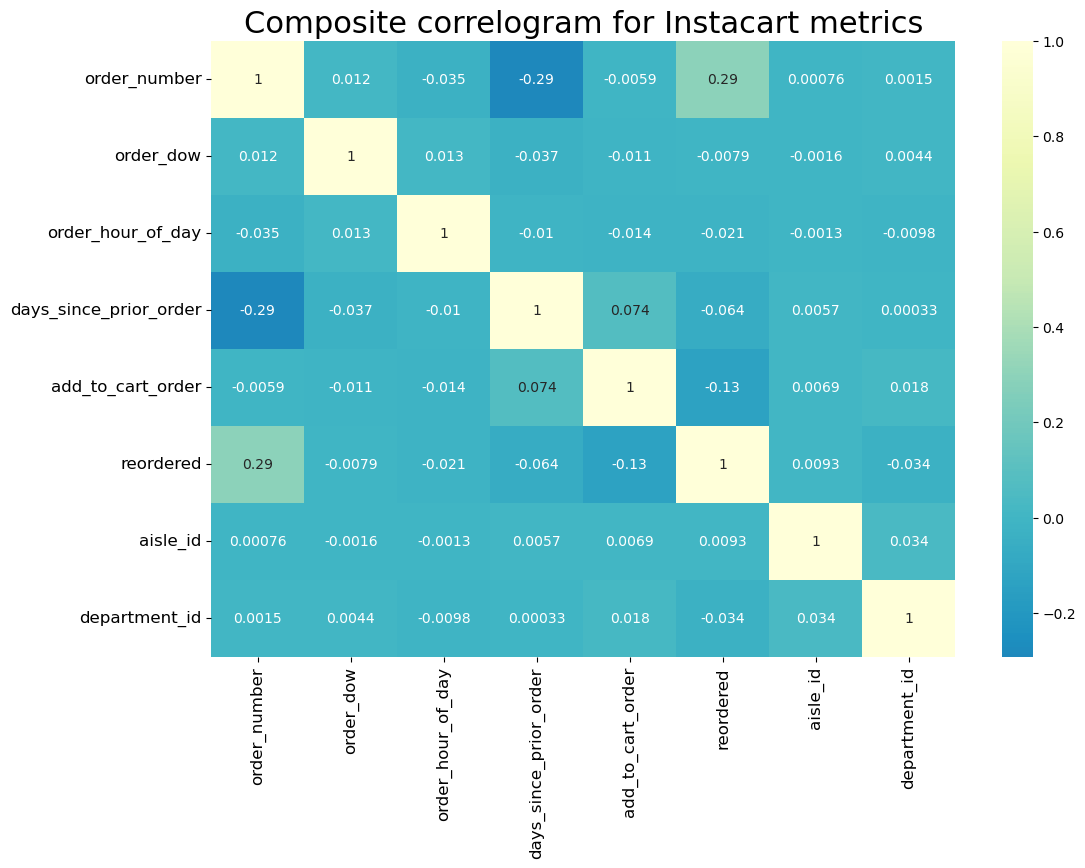

In [8]:
draw_heatmap(main_corr, 'Composite')

Какой-то особенно четкой корреляции между показателями незаметно, но видны небольшие зависимости между показателями порядка добавления в корзину и перезаказами, а также к-вом дней между заказами. Показатель reordered при этом немного связан с показателями номера заказа пользователя (что логично, учитывая, что первый заказ всегда имеет значение 0 по столбцу), а также (очень слабо) - с количеством дней между заказами. Остальные значения совсем мизерны. Поэтому для обучения модели оставим показатели: add_to_cart_order,reordered, days_since_prior_order и order_number. Также, естественно, туда войдут столбцы с id пользователей и товаров.

In [9]:
#Оставим только нужные колонки:
main_n = main.drop(columns = ['product_name', 'aisle','department','aisle_id', 'department_id','order_dow','order_hour_of_day'])
main_n.head()#проверка

,order_id,user_id,order_number,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,1,NaN,196,1.0,0.0
1,2539329,1,1,NaN,14084,2.0,0.0
2,2539329,1,1,NaN,12427,3.0,0.0
3,2539329,1,1,NaN,26088,4.0,0.0
4,2539329,1,1,NaN,26405,5.0,0.0


Теперь на основе имеющихся данных попробуем создать ряд показателей, который может помочь повысить точность предскзазания (т.е. сделаем так называемый feature engineering). Условно можно выделить три группы показателей **user based, product based и user-product based** (в зависимости от того, к чему эти показатели привязаны в первую очередь).

Начнем, по порядку, с показателей, привязанных в первую очередь только к **пользователю** - это его номера заказов, размер корзины и другие приференции. В эту категорию можно отнести и предпочительные дни и часы заказа, но мы решили им пренебречь, т.к. они, похоже, незначительно влияют на значимые для нас показатели.

In [10]:
#Сгруппируем по пользователям и найдем ряд показателей:
user_df = main_n.groupby(by= 'user_id', as_index = False)\
            .agg(total_orders_by_user =('order_number', 'max'), #всего заказов пользователя
                 max_ordlen_by_user = ('add_to_cart_order', 'max'), #максимальная длина корзины пользователя
                 user_reorder_ratio = ('reordered', 'mean')) #среднее значение по столбцу перезаказов для пользователя
user_df.head(10)

,user_id,total_orders_by_user,max_ordlen_by_user,user_reorder_ratio
0,1,10,9.0,0.694915
1,2,14,26.0,0.476923
2,3,11,11.0,0.597561
3,7,20,24.0,0.669903
4,13,12,10.0,0.641975
5,14,13,30.0,0.323810
6,15,21,6.0,0.814286
7,17,40,15.0,0.717687
8,21,33,17.0,0.502439
9,22,14,14.0,0.484848


Далее необходимо сгруппировать данные по пользователям и номерам заказов, иначе при попытке вычислить, например, моду или медиану мы получим некорректные данные.

In [11]:
#Округление до 2-х знаков после запятой
user_df["user_reorder_ratio"] = user_df.user_reorder_ratio.apply(lambda x: round(x,2))

In [12]:
#Сгруппируем по заказам и найдем к-во продуктов в каждом из них:
user_order = main_n.groupby(by=['user_id', 'order_number','days_since_prior_order'], as_index = False)\
            .agg(user_prod_per_order =('product_id', 'count'))
user_order.head(10)

,user_id,order_number,days_since_prior_order,user_prod_per_order
0,1,2,15.0,6
1,1,3,21.0,5
2,1,4,29.0,5
3,1,5,28.0,8
4,1,6,19.0,4
5,1,7,20.0,5
6,1,8,14.0,6
7,1,9,0.0,6
8,1,10,30.0,9
9,2,2,10.0,6


In [13]:
#Найдем среднее к-во продуктов в заказе
user_order['user_prod_per_order_mean'] = user_order.groupby('user_id')['user_prod_per_order'].transform('mean')

In [14]:
#Напишем функцию для вычисления моды
#Будем считать, что мода существует, если такая тенденция встречается в данных n раз:
def group_mode(row, n, return_counts = False):
    #Воспользуемся функцией моды scipy, чтобы найти искомое значение и к-во повторов значения в данных
    mode, count = scipy.stats.mode(row, axis=None)
    #Сравним к-во повторов с нашей границей учета моды и
    if return_counts == False:
        if count < n:
            return None #выведем None, если значение встречается слишком мало, чтобы считать это тенденцией или
        else:
            return mode #выведем моду, если есть подозрение, что она действительно является таковой
    else:
        if count >= n:
            return count

In [15]:
#Применим её к показателю days_since_prior_order, к-во совпадений для причисления к моде будет 3:
user_order['mode_dspo_per_user'] = user_order.groupby('user_id')['days_since_prior_order'].transform(lambda x: group_mode(x,3))
user_order.sample(10)

,user_id,order_number,days_since_prior_order,user_prod_per_order,user_prod_per_order_mean,mode_dspo_per_user
682240,55754,29,8.0,6,15.454545,6.0
2081569,171706,25,1.0,5,5.629630,1.0
52929,4509,14,9.0,15,10.933333,NaN
1200153,98236,40,6.0,14,11.450000,5.0
2226549,183636,13,2.0,1,5.312500,6.0
1896861,155901,42,5.0,9,7.183673,7.0
1019694,83597,10,21.0,9,5.818182,30.0
1122199,91928,49,4.0,1,8.460000,4.0
1197453,98033,37,3.0,5,14.015152,7.0
1050530,86117,52,7.0,5,11.519231,7.0


In [16]:
#Посмотрим, есть ли в итоге пустые значения
user_order.isnull().sum()

user_id                          0
order_number                     0
days_since_prior_order           0
user_prod_per_order              0
user_prod_per_order_mean         0
mode_dspo_per_user          202058
dtype: int64

In [17]:
#Заменим их на среднее по пользователю:
user_order['mode_dspo_per_user'] = user_order['mode_dspo_per_user'].fillna(user_order.groupby('user_id')['days_since_prior_order'].transform('mean'))
user_order.isnull().sum() #check

user_id                     0
order_number                0
days_since_prior_order      0
user_prod_per_order         0
user_prod_per_order_mean    0
mode_dspo_per_user          0
dtype: int64

In [18]:
#Округлим float до 2 знаков после запятой:
user_order["user_prod_per_order_mean"] = user_order.user_prod_per_order_mean.apply(lambda x: round(x,2))

In [19]:
#Добавим результат в user_df
user_df = user_df.merge(user_order, on='user_id', how='left')
user_df.sample(5)

,user_id,total_orders_by_user,max_ordlen_by_user,user_reorder_ratio,order_number,days_since_prior_order,user_prod_per_order,user_prod_per_order_mean,mode_dspo_per_user
983139,80551,25,17.0,0.75,17,6.0,13,12.42,7.0
1830322,150387,63,38.0,0.71,2,4.0,18,15.56,4.0
1048032,85901,61,33.0,0.67,35,2.0,4,12.57,4.0
642518,52672,34,36.0,0.47,21,6.0,16,11.09,4.0
626873,51359,38,24.0,0.73,35,8.0,12,9.46,8.0


In [20]:
#Теперь то же самое по продуктам:
product_df = main_n.groupby(by= 'product_id', as_index = False)\
            .agg(prod_reordered =('reordered', 'sum'), #всего перезаказов по продукту
                 prod_ordered = ('order_id', 'count'), #всего заказов по продукту
                 prod_reorder_ratio = ('reordered', 'mean')) #среднее по перезаказам в разрезе продуктов               
product_df.head(10)

,product_id,prod_reordered,prod_ordered,prod_reorder_ratio
0,1,1051.0,1549,0.678502
1,2,11.0,80,0.137500
2,3,191.0,242,0.789256
3,4,105.0,215,0.488372
4,5,8.0,11,0.727273
5,6,3.0,8,0.375000
6,7,11.0,26,0.423077
7,8,72.0,126,0.571429
8,9,64.0,111,0.576577
9,10,1139.0,2055,0.554258


In [21]:
#Округлим float до 2 знаков после запятой:
product_df["prod_reorder_ratio"] = product_df.prod_reorder_ratio.apply(lambda x: round(x,2))

Для ряда вычислений нам также необходима информация по заказам, только не order_number (номер заказа у пользователя), а именно order_id (id заказа в системе).

In [22]:
#Создадим под это датафрейм product_order:
product_order =  main_n.groupby(['product_id','order_id','add_to_cart_order','reordered'], as_index = False)['days_since_prior_order']\
        .agg("sum") #здесь мы просто оставляем к-во дней как есть
product_order.head(10)

,product_id,order_id,add_to_cart_order,reordered,days_since_prior_order
0,1,5319,3.0,1.0,1.0
1,1,7540,4.0,1.0,7.0
2,1,9273,30.0,0.0,0.0
3,1,9696,5.0,1.0,8.0
4,1,11485,4.0,0.0,24.0
5,1,12672,3.0,1.0,6.0
6,1,13668,4.0,1.0,9.0
7,1,14668,13.0,1.0,7.0
8,1,16132,1.0,1.0,5.0
9,1,18303,1.0,1.0,14.0


In [23]:
#Т.к. мы "пляшем" от продуктов, а не от пользователей, есть смысл кол-во вхождений для отнесения к моде увеличить до 10 раз.
po_modes = product_order.groupby('product_id',as_index = False)\
              .agg(mode_prod_pos =("add_to_cart_order", lambda x: group_mode(x,10)),
                   mode_dspo_by_prod = ("days_since_prior_order", lambda x: group_mode(x,10)))

In [24]:
#Добавим в product_order
product_order = product_order.merge(po_modes, on='product_id', how='left')
product_df =  product_order.merge(product_df, on='product_id', how='left')
product_df.sample(5)

,product_id,order_id,add_to_cart_order,reordered,days_since_prior_order,mode_prod_pos,mode_dspo_by_prod,prod_reordered,prod_ordered,prod_reorder_ratio
13136932,25087,551110,27.0,0.0,13.0,1.0,7.0,555.0,2213,0.25
23764399,45066,1817697,10.0,1.0,5.0,2.0,7.0,51204.0,66175,0.77
20173414,38662,52975,31.0,0.0,3.0,2.0,7.0,2419.0,3294,0.73
3074925,6410,210873,5.0,0.0,29.0,1.0,30.0,121.0,277,0.44
23179422,44329,1210469,5.0,0.0,1.0,2.0,7.0,524.0,933,0.56


In [25]:
#Заменим пустые значения на средние по продукту:
product_df['mode_prod_pos'] = product_df['mode_prod_pos'].fillna(product_df.groupby('product_id')['add_to_cart_order'].transform('mean'))
product_df['mode_dspo_by_prod'] = product_df['mode_dspo_by_prod'].fillna(product_df.groupby('product_id')['days_since_prior_order'].transform('mean'))
product_df.isnull().sum() #check

product_id                0
order_id                  0
add_to_cart_order         0
reordered                 0
days_since_prior_order    0
mode_prod_pos             0
mode_dspo_by_prod         0
prod_reordered            0
prod_ordered              0
prod_reorder_ratio        0
dtype: int64

In [26]:
#Удалим лишние столбцы:
product_df.drop(columns = ['add_to_cart_order','days_since_prior_order'], inplace = True)

In [27]:
# Удалим ненужные df:
del [user_order, product_order, po_modes]
gc.collect()

0

In [28]:
#Теперь product-user:
user_product_df = main_n.groupby(by=['user_id', 'product_id'], as_index = False)\
    .agg(pu_ordered_times =('order_number', 'count'),
         pu_first_order =('order_number', 'min'))
user_product_df.head(10)

,user_id,product_id,pu_ordered_times,pu_first_order
0,1,196,10,1
1,1,10258,9,2
2,1,10326,1,5
3,1,12427,10,1
4,1,13032,3,2
5,1,13176,2,2
6,1,14084,1,1
7,1,17122,1,5
8,1,25133,8,3
9,1,26088,2,1


In [29]:
#Добавим уже посчитанные данные по сумме заказов пользователей:
user_product_df['total_orders_by_user'] = user_product_df['user_id'].map(user_df.total_orders_by_user)
#Найдем соотношение к-ва покупок товара пользователем к релевантному количеству заказов
#Чтобы найти искомое количество заказов, вычтем из всех заказов номер заказа, в котором впервые появился товар
#и прибавим единицу (чтобы учесть этот первый заказ)
user_product_df['pu_order_ratio'] = user_product_df['pu_ordered_times']/(user_product_df['total_orders_by_user'] - user_product_df['pu_first_order'] + 1)
user_product_df.head(10)

,user_id,product_id,pu_ordered_times,pu_first_order,total_orders_by_user,pu_order_ratio
0,1,196,10,1,10,1.000000
1,1,10258,9,2,10,1.000000
2,1,10326,1,5,10,0.166667
3,1,12427,10,1,10,1.000000
4,1,13032,3,2,10,0.333333
5,1,13176,2,2,10,0.222222
6,1,14084,1,1,10,0.100000
7,1,17122,1,5,10,0.166667
8,1,25133,8,3,10,1.000000
9,1,26088,2,1,10,0.200000


In [30]:
#Округлим float:
user_product_df["pu_order_ratio"] = user_product_df.pu_order_ratio.apply(lambda x: round(x,2))

In [31]:
#Удалим лишнее
user_product_df.drop(columns = ['pu_first_order'], inplace=True)

In [32]:
#Будем присоединять всё к main_n по шагам
#Вспомним, что там было:
main_n.head()

,order_id,user_id,order_number,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,1,NaN,196,1.0,0.0
1,2539329,1,1,NaN,14084,2.0,0.0
2,2539329,1,1,NaN,12427,3.0,0.0
3,2539329,1,1,NaN,26088,4.0,0.0
4,2539329,1,1,NaN,26405,5.0,0.0


In [33]:
#Начнем с user_df:
#Merge слишком ресурсозатратен, воспользуемся map:
main_n['max_ordlen_by_user'] = main_n['user_id'].map(user_df['max_ordlen_by_user']) 
main_n['user_reorder_ratio'] = main_n['user_id'].map(user_df['user_reorder_ratio'])
main_n['user_prod_per_order'] = main_n['user_id'].map(user_df['user_prod_per_order'])
main_n['user_prod_per_order_mean'] = main_n['user_id'].map(user_df['user_prod_per_order_mean'])
main_n['mode_dspo_per_user'] = main_n['user_id'].map(user_df['mode_dspo_per_user'])

In [34]:
#Теперь product_df:
main_n['prod_reordered'] = main_n['product_id'].map(product_df['prod_reordered'])
main_n['prod_ordered'] = main_n['product_id'].map(product_df['prod_ordered']) 
main_n['prod_reorder_ratio'] = main_n['product_id'].map(product_df['prod_reorder_ratio'])
main_n['mode_prod_pos'] = main_n['product_id'].map(product_df['mode_prod_pos'])
main_n['mode_dspo_by_prod'] = main_n['product_id'].map(product_df['mode_dspo_by_prod'])

In [35]:
#Проверим:
main_n.head()

,order_id,user_id,order_number,days_since_prior_order,product_id,add_to_cart_order,reordered,max_ordlen_by_user,user_reorder_ratio,user_prod_per_order,user_prod_per_order_mean,mode_dspo_per_user,prod_reordered,prod_ordered,prod_reorder_ratio,mode_prod_pos,mode_dspo_by_prod
0,2539329,1,1,NaN,196,1.0,0.0,9.0,0.69,5,6.0,19.555556,1051.0,1549,0.68,3.0,7.0
1,2539329,1,1,NaN,14084,2.0,0.0,9.0,0.69,5,6.0,19.555556,3447.0,5289,0.65,2.0,7.0
2,2539329,1,1,NaN,12427,3.0,0.0,9.0,0.69,5,6.0,19.555556,3447.0,5289,0.65,2.0,7.0
3,2539329,1,1,NaN,26088,4.0,0.0,9.0,0.69,5,6.0,19.555556,10926.0,15484,0.71,4.0,7.0
4,2539329,1,1,NaN,26405,5.0,0.0,9.0,0.69,5,6.0,19.555556,10926.0,15484,0.71,4.0,7.0


In [36]:
# Освободим память
del [user_df, product_df]
gc.collect()

0

In [37]:
#Так как далее придется всё-таки сделать merge, сохраним main_n, чтобы не запускать постоянно код выше:
main_n.to_csv('./data/recsys/main_n.csv', sep='\t', index=False)
user_product_df.to_csv('./data/recsys/user_product_df.csv', sep='\t', index=False)

In [2]:
#Что очень пригодилось:
main_n = pd.read_csv('./data/recsys/main_n.csv', sep='\t')
user_product_df = pd.read_csv('./data/recsys/user_product_df.csv', sep='\t')

In [3]:
#Воспользуемся join
#Для этого зададим индексы в обоих df, на основании которых мы хотим сделать объединение
main_n = main_n.set_index(['user_id', 'product_id'])
user_product_df = user_product_df.set_index(['user_id', 'product_id'])

In [4]:
#Теперь попробуем объединить всё:
ldf = [main_n, user_product_df]
res_df = reduce(lambda x,y: x.join(y, how = "left"), ldf)

In [5]:
del [user_product_df, main_n]
gc.collect()

0

In [6]:
#И еще save
res_df.to_csv('./data/recsys/res_df.csv', sep='\t', index=True)

In [3]:
#Load
file_path = './data/recsys/res_df.csv'
res_df = pd.read_csv(file_path, sep='\t', index_col=[0,1], skipinitialspace=True)

In [4]:
res_df.head()

order_id  order_number  days_since_prior_order  \
user_id product_id                                                   
1       196          2539329             1                     NaN   
        14084        2539329             1                     NaN   
        12427        2539329             1                     NaN   
        26088        2539329             1                     NaN   
        26405        2539329             1                     NaN   

                    add_to_cart_order  reordered  max_ordlen_by_user  \
user_id product_id                                                     
1       196                       1.0        0.0                 9.0   
        14084                     2.0        0.0                 9.0   
        12427                     3.0        0.0                 9.0   
        26088                     4.0        0.0                 9.0   
        26405                     5.0        0.0                 9.0   

                    user_reorder_ratio  user_prod_per_order  \
user_id product_id                                            
1       196                       0.69                    5   
        14084                     0.69                    5   
        12427                     0.69                    5   
        26088                     0.69                    5   
        26405                     0.69                    5   

                    user_prod_per_order_mean  mode_dspo_per_user  \
user_id product_id                                                 
1       196                              6.0           19.555556   
        14084                            6.0           19.555556   
        12427                            6.0           19.555556   
        26088                            6.0           19.555556   
        26405                            6.0           19.555556   

                    prod_reordered  prod_ordered  prod_reorder_ratio  \
user_id product_id                                                     
1       196                 1051.0          1549                0.68   
        14084               3447.0          5289                0.65   
        12427               3447.0          5289                0.65   
        26088              10926.0         15484                0.71   
        26405              10926.0         15484                0.71   

                    mode_prod_pos  mode_dspo_by_prod  pu_ordered_times  \
user_id product_id                                                       
1       196                   3.0                7.0                10   
        14084                 2.0                7.0                 1   
        12427                 2.0                7.0                10   
        26088                 4.0                7.0                 2   
        26405                 4.0                7.0                 2   

                    total_orders_by_user  pu_order_ratio  
user_id product_id                                        
1       196                           10             1.0  
        14084                         10             0.1  
        12427                         10             1.0  
        26088                         10             0.2  
        26405                         10             0.2

In [7]:
#Теперь уберем индекс (пока не нужен) и посмотрим на значения поближе:
res_df = res_df.reset_index()
res_df.head()

,user_id,product_id,order_id,order_number,days_since_prior_order,add_to_cart_order,reordered,max_ordlen_by_user,user_reorder_ratio,user_prod_per_order,user_prod_per_order_mean,mode_dspo_per_user,prod_reordered,prod_ordered,prod_reorder_ratio,mode_prod_pos,mode_dspo_by_prod,pu_ordered_times,total_orders_by_user,pu_order_ratio
0,1,196,2539329,1,NaN,1.0,0.0,9.0,0.69,5,6.0,19.555556,1051.0,1549,0.68,3.0,7.0,10,10,1.0
1,1,14084,2539329,1,NaN,2.0,0.0,9.0,0.69,5,6.0,19.555556,3447.0,5289,0.65,2.0,7.0,1,10,0.1
2,1,12427,2539329,1,NaN,3.0,0.0,9.0,0.69,5,6.0,19.555556,3447.0,5289,0.65,2.0,7.0,10,10,1.0
3,1,26088,2539329,1,NaN,4.0,0.0,9.0,0.69,5,6.0,19.555556,10926.0,15484,0.71,4.0,7.0,2,10,0.2
4,1,26405,2539329,1,NaN,5.0,0.0,9.0,0.69,5,6.0,19.555556,10926.0,15484,0.71,4.0,7.0,2,10,0.2


In [8]:
#И еще save
res_df.to_csv('./data/recsys/res_df.csv', sep='\t', index=False)

In [9]:
#Проверка на "нули":
res_df.isnull().sum()

user_id                           0
product_id                        0
order_id                          0
order_number                      0
days_since_prior_order      1045204
add_to_cart_order                 0
reordered                         0
max_ordlen_by_user                0
user_reorder_ratio                0
user_prod_per_order               0
user_prod_per_order_mean          0
mode_dspo_per_user                0
prod_reordered                    0
prod_ordered                      0
prod_reorder_ratio                0
mode_prod_pos                     0
mode_dspo_by_prod                 0
pu_ordered_times                  0
total_orders_by_user              0
pu_order_ratio                    0
dtype: int64

In [10]:
#Nan в данной категории появляются в первом заказе
#Заменим на средние в группировке по пользователям
res_df['days_since_prior_order'] = res_df['days_since_prior_order'].fillna(res_df.groupby('user_id')['days_since_prior_order'].transform('mean'))

In [11]:
#Le check 2
res_df.isnull().sum()

user_id                     0
product_id                  0
order_id                    0
order_number                0
days_since_prior_order      0
add_to_cart_order           0
reordered                   0
max_ordlen_by_user          0
user_reorder_ratio          0
user_prod_per_order         0
user_prod_per_order_mean    0
mode_dspo_per_user          0
prod_reordered              0
prod_ordered                0
prod_reorder_ratio          0
mode_prod_pos               0
mode_dspo_by_prod           0
pu_ordered_times            0
total_orders_by_user        0
pu_order_ratio              0
dtype: int64

In [12]:
#Финальная проверка на адекватность значений:
res_df.describe().map(lambda x: f"{x:0.3f}")#check

,user_id,product_id,order_id,order_number,days_since_prior_order,add_to_cart_order,reordered,max_ordlen_by_user,user_reorder_ratio,user_prod_per_order,user_prod_per_order_mean,mode_dspo_per_user,prod_reordered,prod_ordered,prod_reorder_ratio,mode_prod_pos,mode_dspo_by_prod,pu_ordered_times,total_orders_by_user,pu_order_ratio
count,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000,26408073.000
mean,102886.385,25572.530,1709982.734,19.889,9.887,8.364,0.642,21.788,0.633,10.087,10.116,8.215,4485.955,6565.715,0.611,3.622,7.450,8.729,39.886,inf
std,59458.791,14084.181,987309.952,17.996,7.764,7.139,0.479,10.963,0.157,7.442,5.441,8.008,4745.055,6593.503,0.152,1.950,4.012,10.395,25.390,nan
min,1.000,1.000,3.000,1.000,0.000,1.000,0.000,1.000,0.020,1.000,1.000,0.000,0.000,2.000,0.000,1.000,0.000,1.000,9.000,-55.000
25%,51309.000,13535.000,855565.000,7.000,5.000,3.000,0.000,14.000,0.530,5.000,6.370,3.000,393.000,849.000,0.580,2.000,7.000,2.000,19.000,0.050
50%,102513.000,25211.000,1709741.000,14.000,7.000,6.000,1.000,20.000,0.650,8.000,9.210,6.000,1692.000,2942.000,0.660,4.000,7.000,5.000,33.000,0.170
75%,154297.000,37904.000,2564804.000,27.000,13.000,11.000,1.000,28.000,0.760,14.000,12.920,8.000,10926.000,15484.000,0.710,4.000,7.000,11.000,54.000,0.470
max,206209.000,49688.000,3421083.000,99.000,30.000,145.000,1.000,95.000,0.980,92.000,49.810,30.000,10926.000,15484.000,0.820,21.667,30.000,99.000,99.000,inf


In [15]:
print(' Total users:', res_df.user_id.nunique(),'\n','Total products:', res_df.product_id.nunique())

 Total users: 100000 
 Total products: 49465


In [18]:
res_df.replace([np.inf, -np.inf], 0, inplace=True) #пропустила деление на ноль, заменим нулями
res_df.to_csv('./data/recsys/res_df.csv', sep='\t', index=False)#И сохранимся еще раз на всякий...

In [2]:
#Load
file_path = './data/recsys/res_df.csv'
res_df = pd.read_csv(file_path, sep='\t')

In [3]:
#Разделим данные на train и testset, абсолютно так же, как мы это делали ранее:
testset = res_df[res_df['order_number'] == res_df['total_orders_by_user']]
trainset = res_df[res_df['order_number'] != res_df['total_orders_by_user']]
set_len = trainset.shape[0] + testset.shape[0]
print('\n К-во строк в тренировочном сете: ', trainset.shape[0], '\n','В тестовом сете ', testset.shape[0])
print('\n В процентом соотношении: ', round(100*(trainset.shape[0]/set_len),1), '% к ', 
      round(100*(testset.shape[0]/set_len),1), '%')


 К-во строк в тренировочном сете:  26075654 
 В тестовом сете  332419

 В процентом соотношении:  98.7 % к  1.3 %


In [8]:
trainset.user_id.nunique() #check

100000

In [9]:
#Сохраним train и test
trainset.to_csv('./data/recsys/train_xgb.csv', sep='\t', index=False)
testset.to_csv('./data/recsys/test_xgb.csv', sep='\t', index=False)

## Оптимизация и обучение модели

In [2]:
#Загрузим train и test:
trainset = pd.read_csv('./data/recsys/train_xgb.csv', sep='\t')
testset = pd.read_csv('./data/recsys/test_xgb.csv', sep='\t')

In [3]:
#Удалим лишние столбцы - это номера заказов и порядок добавления товаров в корзину:
cols_to_drop = ['order_id','order_number','add_to_cart_order']
trainset = trainset.drop(cols_to_drop, axis=1)

In [4]:
# Установим индексами user_id и product_id
trainset = trainset.set_index(['user_id', 'product_id'])
# Установим X и y:
X_train = trainset.drop('reordered', axis=1)
y_train = trainset.reordered

In [5]:
# Определим границы проверки ряда параметров
xgboost_space= {
            #к-во деревьев
            'n_estimators': hp.choice('x_n_estimators',np.arange(25,100,5)),
            #максимальная глубина деревьев
            'max_depth': hp.choice('x_max_depth',[2,3,4,5,6]),
            # Минимальная сумма веса экземпляра , необходимая для выполнения разделения. Предотвращает переобучение                       
            'min_child_weight':hp.uniform('x_min_child_weight', 1, 10),
            #минимальное изменение значения loss функции для разделения листа на поддеревья
            'gamma': hp.uniform ('x_gamma', 1,9),
            #L1 регуляризация (lasso regression). Увеличение этого значения сделает модель более консервативной.
            'reg_alpha' : hp.quniform('x_reg_alpha', 50, 200, 1),
            #L2 регуляризация  (ridge regression). Увеличение этого значения сделает модель более консервативной.
            'reg_lambda' : hp.uniform('x_reg_lambda', 0, 1),
            #Размер шага. Предотвращает переобучение
            'learning_rate':hp.loguniform('x_learning_rate', -0.3, 0.3),
            #Доля переменных (features), используемых при построении каждого дерева. Предотвращает переобучение                      
            'colsample_bytree':hp.uniform('x_colsample_bytree', 0.5, 1),
            #Доля тренировочных данных, используемая при построении каждого дерева. Аналогично.                        
            'subsample':hp.uniform('x_subsample', 0.5, 1)
                
                                       }



def objective(space):
    model = xgb.XGBClassifier(**space, objective='binary:logistic',eval_metric='logloss', nthread = -1)
    kfold = KFold(n_splits=3, random_state=123, shuffle=True)
    score = -cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_log_loss', verbose=False).mean()
    print("Current score: ", score)
    K.clear_session()
    del model
    gc.collect()
    return score 

start = time.time()

best = fmin(
  objective, 
  space = xgboost_space, 
  algo = tpe.suggest, 
  max_evals = 100,
  trials = Trials())

print("Hyperopt search took %.2f seconds for 100 candidates" % ((time.time() - start)))
print("Best space: ", best)

Current score:                                                                                                          
0.29665653767931405                                                                                                     
Current score:                                                                                                          
0.2960553722338316                                                                                                      
Current score:                                                                                                          
0.2956320061187992                                                                                                      
Current score:                                                                                                          
0.3121904340663249                                                                                                      
Current score:                  

Current score:                                                                                                          
0.29417795991131684                                                                                                     
Current score:                                                                                                          
0.29422334301659786                                                                                                     
Current score:                                                                                                          
0.2938578971132823                                                                                                      
Current score:                                                                                                          
0.2944918696636833                                                                                                      
Current score:                  

In [5]:
best_space_dict =  {'x_colsample_bytree': 0.971177335771276, 'x_gamma': 1.2810392094362184, 'x_learning_rate': 1.281023565874645, 'x_max_depth': 4, 'x_min_child_weight': 7.3422308388730055, 'x_n_estimators': 13, 'x_reg_alpha': 77.0, 'x_reg_lambda': 0.8738651741214771, 'x_subsample': 0.9719979413835671}

In [6]:
#Запустим модель с лучшим набором параметров:
best_clf = xgb.XGBClassifier(objective='binary:logistic',
                             eval_metric='logloss', 
                             n_estimators = int(best_space_dict['x_n_estimators']), 
                             learning_rate = best_space_dict['x_learning_rate'], 
                             max_depth = int(best_space_dict['x_max_depth']), 
                             gamma = best_space_dict['x_gamma'], 
                             reg_alpha = int(best_space_dict['x_reg_alpha']),
                             reg_lambda = best_space_dict['x_reg_lambda'],
                             min_child_weight = best_space_dict['x_min_child_weight'], 
                             colsample_bytree = best_space_dict['x_colsample_bytree'],
                             subsample = best_space_dict['x_subsample'],
                             nthread = -1)

In [7]:
#Обучение на наших данных
best_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.971177335771276, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=1.2810392094362184, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1.281023565874645,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=7.3422308388730055, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=13,
              n_jobs=None, nthread=-1, num_parallel_tree=None, ...)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

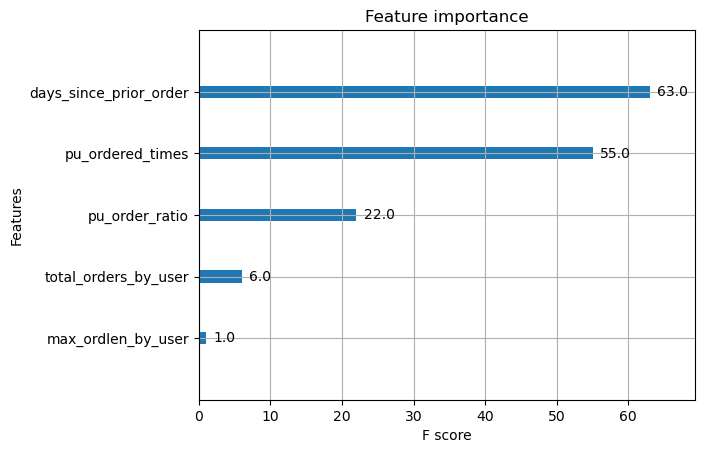

In [8]:
#Посмотрим на важность тех или иных столбцов в нашей модели:
xgb.plot_importance(best_clf)

In [9]:
#Сделаем базовое предсказание на X_test:
testset = testset.drop(cols_to_drop, axis=1)
testset = testset.set_index(['user_id', 'product_id'])
# Установим X и y:
X_test = testset.drop('reordered', axis=1)
y_test = testset.reordered
Y_pred = best_clf.predict(X_test)

Text(0.5, 1.0, 'Confusion Matrix for Instacart orders')

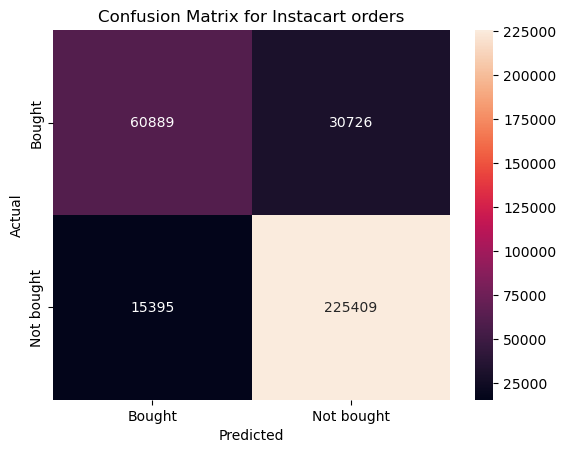

In [10]:
#Опрделелим данные для confusion matrix:
cm = confusion_matrix(y_test, Y_pred)
labels = ['Bought', 'Not bought']
#Отрисуем результат:
sns.heatmap(cm, annot = True, xticklabels = labels, yticklabels = labels, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Instacart orders')

In [11]:
#Еще посмотрим на ряд метрик:
from sklearn.metrics import f1_score, classification_report
#Вычислим полноту,точность и f1-score (общий и по категориям)
print(f'f1 Score: {f1_score(Y_pred, y_test)}')
print(classification_report(Y_pred, y_test))

f1 Score: 0.9071898160538818
              precision    recall  f1-score   support

           0       0.66      0.80      0.73     76284
           1       0.94      0.88      0.91    256135

    accuracy                           0.86    332419
   macro avg       0.80      0.84      0.82    332419
weighted avg       0.87      0.86      0.87    332419



Этот вариант показывает хорошее соотношение между полнотой и точностью предсказния в рамках обоих классов, общий f1 score также достаточно высокий. Попробуем предсказание на таком варианте.

In [12]:
#Уберем дубликаты из X_train
new_train =  X_train[~X_train.index.duplicated(keep='first')]
new_train.head(15)

days_since_prior_order  max_ordlen_by_user  \
user_id product_id                                               
1       196                      20.259259                 9.0   
        14084                    20.259259                 9.0   
        12427                    20.259259                 9.0   
        26088                    20.259259                 9.0   
        26405                    20.259259                 9.0   
        10258                    15.000000                 9.0   
        13176                    15.000000                 9.0   
        13032                    15.000000                 9.0   
        25133                    21.000000                 9.0   
        30450                    21.000000                 9.0   
        10326                    28.000000                 9.0   
        17122                    28.000000                 9.0   
        41787                    28.000000                 9.0   
        46149                    14.000000                 9.0   
        49235                    14.000000                 9.0   

                    user_reorder_ratio  user_prod_per_order  \
user_id product_id                                            
1       196                       0.69                    5   
        14084                     0.69                    5   
        12427                     0.69                    5   
        26088                     0.69                    5   
        26405                     0.69                    5   
        10258                     0.69                    5   
        13176                     0.69                    5   
        13032                     0.69                    5   
        25133                     0.69                    5   
        30450                     0.69                    5   
        10326                     0.69                    5   
        17122                     0.69                    5   
        41787                     0.69                    5   
        46149                     0.69                    5   
        49235                     0.69                    5   

                    user_prod_per_order_mean  mode_dspo_per_user  \
user_id product_id                                                 
1       196                              6.0           19.555556   
        14084                            6.0           19.555556   
        12427                            6.0           19.555556   
        26088                            6.0           19.555556   
        26405                            6.0           19.555556   
        10258                            6.0           19.555556   
        13176                            6.0           19.555556   
        13032                            6.0           19.555556   
        25133                            6.0           19.555556   
        30450                            6.0           19.555556   
        10326                            6.0           19.555556   
        17122                            6.0           19.555556   
        41787                            6.0           19.555556   
        46149                            6.0           19.555556   
        49235                            6.0           19.555556   

                    prod_reordered  prod_ordered  prod_reorder_ratio  \
user_id product_id                                                     
1       196                 1051.0          1549                0.68   
        14084               3447.0          5289                0.65   
        12427               3447.0          5289                0.65   
        26088              10926.0         15484                0.71   
        26405              10926.0         15484                0.71   
        10258               3447.0          5289                0.65   
        13176               3447.0          5289                0.65   
        13032       

In [13]:
#Теперь получим предсказание по train-набору данных, в котором, в отличие от test, представлены все пользователи:
reorder_pred = best_clf.predict(new_train)

In [14]:
#Отсавим только нужное
reorder_df = new_train.reset_index()
reorder_df['reorder_pred'] = reorder_pred
reorder_df = reorder_df[['user_id','product_id','reorder_pred']]
reorder_df.head(15)

,user_id,product_id,reorder_pred
0,1,196,1
1,1,14084,0
2,1,12427,1
3,1,26088,0
4,1,26405,0
5,1,10258,1
6,1,13176,0
7,1,13032,1
8,1,25133,1
9,1,30450,0


## ALS + reorder prediction

Попробуем загрузить сюда ALS-модель с предсказанием порядка покупки и совместим с текущим результатом для итогового предсказания.

In [15]:
from surprise import Dataset, Reader
from surprise.model_selection import PredefinedKFold
from surprise import BaselineOnly
#Для подачи в модели:
files_dir = './data/recsys/'

TRAIN_CSV_PATH = os.path.join(files_dir, 'train_df.csv')
TEST_CSV_PATH = os.path.join(files_dir, 'test_df.csv')

reader = Reader(line_format="user item rating", sep = '\t',rating_scale=(1, 10)) # Зададим разброс оценок

folds_files = [(TRAIN_CSV_PATH,TEST_CSV_PATH)] #список путей к файлам для подачи в объект библиотеки surprise lib
data = Dataset.load_from_folds(folds_files, reader=reader) #создадим data-объект

pkf = PredefinedKFold() #создадим объект, позволяющий подать в модель собственный набор train и test данных
train_als, test_als = next(pkf.split(data)) #определим train и test сеты

#Установим модель с лучшим результатом:
bsl_options =  {'method': 'als', 'n_epochs': 20, 'reg_u': 18, 'reg_i': 6}
algo = BaselineOnly(bsl_options = bsl_options)

In [16]:
%%time
#Сделаем предсказание:
predictions = algo.fit(train_als).test(test_als)

Estimating biases using als...
CPU times: user 11.4 s, sys: 0 ns, total: 11.4 s
Wall time: 11.4 s


In [17]:
#Соберем в сет:
appended_data = []
for i in predictions:
    appended_data.append(i)
pred_df = pd.DataFrame(appended_data, columns = ['user_id','product_id','real_rating','predicted_rating','details'])
pred_df.drop(columns = ["details"], inplace = True)

In [18]:
#Для корректного объединения типы данных в pred_df нужно будет поменять:
pred_df = pred_df.astype({"user_id": int, "product_id": int})

In [19]:
#Объединим результаты двух моделей в один датасет (pred_df) с помощью join
#Для этого для начала установим нужные индексы:
pred_set = pred_df.set_index(['user_id', 'product_id'])
reorder_set = reorder_df.set_index(['user_id', 'product_id'])

In [20]:
#Воспользуемся join:
ldf = [pred_set, reorder_set]
pred_set = reduce(lambda x,y: x.join(y, how = "left"), ldf)

In [21]:
pred_set.head(15) #снова check

real_rating  predicted_rating  reorder_pred
user_id product_id                                             
1       196                10.0          4.170846           1.0
        46149               9.0          4.080973           1.0
        39657               8.0          3.351688           NaN
        38928               7.0          4.115123           NaN
        25133               6.0          2.929239           1.0
        10258               5.0          2.933067           1.0
        35951               4.0          3.407510           NaN
        13032               3.0          2.488235           1.0
        12427               2.0          3.196634           1.0
2       24852              10.0          4.943528           1.0
        16589               9.0          2.356979           1.0
        1559                8.0          2.376852           1.0
        19156               7.0          2.121500           1.0
        18523               6.0          2.584406           1.0
        22825               5.0          1.921481           0.0

In [22]:
#Попробуем менее строгое объединение - заменим Nan на единицы:
# pred_set['reorder_pred'] = pred_set['reorder_pred'].fillna(0)
pred_set['reorder_pred'] = pred_set['reorder_pred'].fillna(1)
pred_set = pred_set.reset_index()
pred_set.head(15)

,user_id,product_id,real_rating,predicted_rating,reorder_pred
0,1,196,10.0,4.170846,1.0
1,1,46149,9.0,4.080973,1.0
2,1,39657,8.0,3.351688,1.0
3,1,38928,7.0,4.115123,1.0
4,1,25133,6.0,2.929239,1.0
5,1,10258,5.0,2.933067,1.0
6,1,35951,4.0,3.407510,1.0
7,1,13032,3.0,2.488235,1.0
8,1,12427,2.0,3.196634,1.0
9,2,24852,10.0,4.943528,1.0


In [23]:
#Перемножим результаты двух предсказаний, чтобы обнулить рейтинг некупленных по предсказанию товаров:
pred_set["predicted_rating"] = pred_set["predicted_rating"] * pred_set["reorder_pred"]
pred_set.drop(columns = ["reorder_pred"], inplace = True)
pred_set.head(15)

,user_id,product_id,real_rating,predicted_rating
0,1,196,10.0,4.170846
1,1,46149,9.0,4.080973
2,1,39657,8.0,3.351688
3,1,38928,7.0,4.115123
4,1,25133,6.0,2.929239
5,1,10258,5.0,2.933067
6,1,35951,4.0,3.407510
7,1,13032,3.0,2.488235
8,1,12427,2.0,3.196634
9,2,24852,10.0,4.943528


In [24]:
#Теперь повторим всё то, что делали ранее для сбора предсказаний по ALS
#Обрезка до 10 самых крупных значений:
pred_df = pred_set[pred_set["predicted_rating"] >0]
pred_grouped = pred_df.merge(pred_df
        #Сгруппируем по пользователям, найдем 10 макс значений предсказанного рейтинга
        .groupby('user_id').predicted_rating.nlargest(10)
        #Получим новый df с  MultiIndex, котрый сбросим через reset_index
        .reset_index('user_id'),
        # в новом df нет колонки "product_id" поэтому необходимо объединить изначальный сет с полученным
    how='right') # при этом все строки, которых нет в новом df удалятся
#Проверка
pred_grouped.head(15)

,user_id,product_id,real_rating,predicted_rating
0,1,196,10.0,4.170846
1,1,38928,7.0,4.115123
2,1,46149,9.0,4.080973
3,1,35951,4.0,3.407510
4,1,39657,8.0,3.351688
5,1,12427,2.0,3.196634
6,1,10258,5.0,2.933067
7,1,25133,6.0,2.929239
8,1,13032,3.0,2.488235
9,2,24852,10.0,4.943528


In [25]:
#Соберем все id продуктов в один столбец - pred_order:
pred_result = pred_grouped.groupby('user_id')['product_id'].unique().reset_index()
pred_result.columns=['user_id','pred_order']
#Check
pred_result.head(15)

,user_id,pred_order
0,1,"[196, 38928, 46149, 35951, 39657, 12427, 10258..."
1,2,"[24852, 47209, 33754, 18523, 1559, 7781, 16589..."
2,3,"[47766, 21903, 39190, 17668, 43961]"
3,7,"[40852, 21137, 37602, 47272, 30391, 27690, 131..."
4,13,"[27435, 43086, 42248]"
5,14,"[29509, 15172, 15869, 23803, 37266, 8744, 1113..."
6,15,"[196, 48142]"
7,17,"[14146, 7350, 18534, 16797, 9006, 26767]"
8,21,"[18523, 28204, 27548, 31387]"
9,22,"[24964, 24506]"


In [26]:
#Таким же образом соберем факт:
fact_df = pd.DataFrame(appended_data, columns = ['user_id','product_id','real_rating','predicted_rating','details'])
fact_df = fact_df.astype({"user_id": int, "product_id": int})

fact_df = fact_df.merge(fact_df
        #Сгруппируем по пользователям, найдем 10 макс значений предсказанного рейтинга
        .groupby('user_id').real_rating.nlargest(10)
        #Получим новый df с  MultiIndex, котрый сбросим через reset_index
        .reset_index('user_id'),
        # в новом df нет колонки "product_id" поэтому необходимо объединить изначальный сет с полученным
    how='right') # при этом все строки, которых нет в новом df удалятся
#Проверка
fact_df.head(15)

,user_id,product_id,real_rating,predicted_rating,details
0,1,196,10.0,4.170846,{'was_impossible': False}
1,1,46149,9.0,4.080973,{'was_impossible': False}
2,1,39657,8.0,3.351688,{'was_impossible': False}
3,1,38928,7.0,4.115123,{'was_impossible': False}
4,1,25133,6.0,2.929239,{'was_impossible': False}
5,1,10258,5.0,2.933067,{'was_impossible': False}
6,1,35951,4.0,3.407510,{'was_impossible': False}
7,1,13032,3.0,2.488235,{'was_impossible': False}
8,1,12427,2.0,3.196634,{'was_impossible': False}
9,2,24852,10.0,4.943528,{'was_impossible': False}


In [27]:
fact_df = fact_df.groupby('user_id')['product_id'].unique().reset_index()
fact_df.columns=['user_id','fact_order']
#Check
fact_df.head(15)

,user_id,fact_order
0,1,"[196, 46149, 39657, 38928, 25133, 10258, 35951..."
1,2,"[24852, 16589, 1559, 19156, 18523, 22825, 2741..."
2,3,"[39190, 47766, 21903, 43961, 17668]"
3,7,"[47272, 29993, 31683, 27690, 9598, 13198, 3039..."
4,13,"[27435, 27086, 4210, 43086, 34382, 41926, 1419..."
5,14,"[39399, 29509, 23803, 15869, 8744, 37266, 1113..."
6,15,"[196, 48142]"
7,17,"[7350, 18534, 9006, 26767, 14146, 16797, 18567..."
8,21,"[25740, 6576, 17982, 25513, 8214, 18523, 24799..."
9,22,"[35221, 24964, 7948, 24506]"


In [28]:
result = fact_df.merge(pred_result, how = 'left')
result.head()

,user_id,fact_order,pred_order
0,1,"[196, 46149, 39657, 38928, 25133, 10258, 35951...","[196, 38928, 46149, 35951, 39657, 12427, 10258..."
1,2,"[24852, 16589, 1559, 19156, 18523, 22825, 2741...","[24852, 47209, 33754, 18523, 1559, 7781, 16589..."
2,3,"[39190, 47766, 21903, 43961, 17668]","[47766, 21903, 39190, 17668, 43961]"
3,7,"[47272, 29993, 31683, 27690, 9598, 13198, 3039...","[40852, 21137, 37602, 47272, 30391, 27690, 131..."
4,13,"[27435, 27086, 4210, 43086, 34382, 41926, 1419...","[27435, 43086, 42248]"


In [29]:
#Наши показатели:
def Avg_Precision_at_n(fact, predicted, n=10):
    """
    Вычисление средней точности по n-позициям для двух списков значений.
    
    Вход
    ----------
    fact : list
             Фактический список элементов, который нужно предсказать.
    predicted : list
             Список, полученный в результате предсказания модели (строго упорядоченный).
    n : int
             Максимальное количество предсказываемых позиций
    Выход
    -------
    score : double
            Средняя точность на n-позициях
    """
    if not fact:
        return 0.0

    if len(predicted)>n:
        predicted = predicted[:n]

    score = 0.0
    num_hits = 0.0

    for i,p in enumerate(predicted):
        # Первое условие проверяет наличие предсказания в списке фактических элементов
        # второе условие - проверка на отсутствие (или наличие) повторов в предсказании
        if p in fact and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i+1.0)

    return score / min(len(fact), n)

def MAP_at_n(fact, predicted, n=10):
    """
    Вычисление mean average precision at n для двух списков элементов.
   
    Вход
    ----------
    fact : list
            Фактический список элементов, который нужно предсказать.
    predicted : list
            Список, полученный в результате предсказания модели (строго упорядоченный).
    n : int
            Максимальное количество предсказываемых позиций
    Выход
    -------
    score : double
            Mean average precision at n двух списков
    """
    
    return np.mean([Avg_Precision_at_n(f,p,n) for f,p in zip(fact, predicted)])

In [30]:
#Применим функцию MAP_at_n построчно:
result['fact_order'] = result['fact_order'].astype(str)
result['pred_order'] = result['pred_order'].astype(str) 
result['MAP'] = result.apply(lambda x: MAP_at_n(x.fact_order, x.pred_order), axis=1)
result.head()

,user_id,fact_order,pred_order,MAP
0,1,[ 196 46149 39657 38928 25133 10258 35951 130...,[ 196 38928 46149 35951 39657 12427 10258 251...,0.381818
1,2,[24852 16589 1559 19156 18523 22825 27413 337...,[24852 47209 33754 18523 1559 7781 16589 191...,0.345455
2,3,[39190 47766 21903 43961 17668],[47766 21903 39190 17668 43961],0.258065
3,7,[47272 29993 31683 27690 9598 13198 30391 376...,[40852 21137 37602 47272 30391 27690 13198 299...,0.344262
4,13,[27435 27086 4210 43086 34382 41926 14197 42248],[27435 43086 42248],0.631579


In [31]:
sum(result.MAP)/len(result.user_id.unique())

0.38211960086906593

In [32]:
#Это выше результата просто ALS
#Проверим точность на этом предсказании в Kaggle:
pred_gr = pred_set.merge(pred_set
        #Сгруппируем по пользователям, найдем 10 макс значений предсказанного рейтинга
        .groupby('user_id').predicted_rating.nlargest(10)
        #Получим новый df с  MultiIndex, котрый сбросим через reset_index
        .reset_index('user_id'),
        # в новом df нет колонки "product_id" поэтому необходимо объединить изначальный сет с полученным
    how='right') # при этом все строки, которых нет в новом df удалятся
pred_gr['product_id'] = pred_gr['product_id'].astype(str)
pred_gr.head(15)

,user_id,product_id,real_rating,predicted_rating
0,1,196,10.0,4.170846
1,1,38928,7.0,4.115123
2,1,46149,9.0,4.080973
3,1,35951,4.0,3.407510
4,1,39657,8.0,3.351688
5,1,12427,2.0,3.196634
6,1,10258,5.0,2.933067
7,1,25133,6.0,2.929239
8,1,13032,3.0,2.488235
9,2,24852,10.0,4.943528


In [33]:
prediction_df = pred_gr.groupby('user_id')['product_id'].agg(' '.join).reset_index(name='product_id')
#Cохраним
prediction_df.to_csv('./data/recsys/prediction_reorder.csv',sep=',', index=False)

Теперь когда мы разобрались с предсказанием факта осуществления (или нет) повторной покупки товара в последнем заказе, попробуем воспользоваться XGB для предсказания add_to_cart_order.

In [35]:
#Сохраним в df предсказание только по столбцу reordered, т.е. только user-product-reordered:
reorder_df.to_csv('./data/recsys/basic_reorder_by_prod.csv',sep='\t', index=False)